***Case study 1: Ảnh MNIST – Thiết kế 2 mô hình CNN có và không có Keras***

• Mục tiêu: phân loại chữ số viết tay

• Tập data: MNIST + 100 ảnh sinh viên tự tạo ra. Thể hiện phân bố data

• Sinh viên mô tả: kiến trúc CNN + dropout + kết quả dự đoán + đánh giá 2 mô hình

***Cell 1: Import libraries***

In [1]:
# ========================
# B22DCCN476 - Đỗ Ngọc Lâm
# ========================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image  

import tensorflow as tf
from tensorflow.keras import layers, models 

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # vẽ heatmap

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


***Cell 2: Load & preprocess MNIST dataset***

In [2]:
# ========================================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ========================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Original MNIST shapes:")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape, "y_test :", y_test.shape)

# Chuẩn hoá về [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Thêm channel dimension: (N, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

print("\nAfter reshape:")
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

num_classes = 10


Original MNIST shapes:
x_train: (60000, 28, 28) y_train: (60000,)
x_test : (10000, 28, 28) y_test : (10000,)

After reshape:
x_train: (60000, 28, 28, 1)
x_test : (10000, 28, 28, 1)


***Cell 3: Load self-created digit images***

In [3]:
# ==========================================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ==========================================================

def load_custom_digits_pil(root_dir=r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy1\self-dataset"):
    """
    Đọc ảnh chữ số tự tạo trong 10 folder con: 0,1,2,...,9
    - Mỗi folder chứa các ảnh của đúng nhãn đó.
    - Ảnh sẽ được:
        + đọc grayscale
        + resize về 28x28
        + chuẩn hoá về [0,1]
        + thêm channel dimension -> (28,28,1)
    """
    x_list = []
    y_list = []

    if not os.path.isdir(root_dir):
        print("[ERROR] Không tìm thấy thư mục:", root_dir)
        return None, None

    for digit in range(10):
        label_folder = os.path.join(root_dir, str(digit))
        if not os.path.isdir(label_folder):
            print(f"[WARN] Không tìm thấy folder cho nhãn {digit}: {label_folder}, bỏ qua...")
            continue

        image_paths = glob.glob(os.path.join(label_folder, "*.*"))
        if len(image_paths) == 0:
            print(f"[WARN] Folder {label_folder} không có ảnh, bỏ qua...")
            continue

        print(f"[INFO] Đang load {len(image_paths)} ảnh trong folder nhãn {digit} ...")

        for path in image_paths:
            try:
                img = Image.open(path).convert("L")  # grayscale
            except Exception as e:
                print(f"[WARN] Không đọc được ảnh: {path}, lỗi: {e}, bỏ qua...")
                continue

            # Resize về 28x28
            img = img.resize((28, 28))

            # Convert sang numpy và chuẩn hoá [0,1]
            img_arr = np.array(img).astype("float32") / 255.0

            # Thêm channel dimension (28,28,1)
            img_arr = np.expand_dims(img_arr, axis=-1)

            x_list.append(img_arr)
            y_list.append(digit)

    if len(x_list) == 0:
        print("[WARN] Không load được ảnh nào từ self-dataset.")
        return None, None

    x_custom = np.stack(x_list, axis=0)
    y_custom = np.array(y_list, dtype=np.int32)

    print("Loaded custom digits (PIL):")
    print("x_custom:", x_custom.shape, "y_custom:", y_custom.shape)
    return x_custom, y_custom


x_custom, y_custom = load_custom_digits_pil()


[INFO] Đang load 10 ảnh trong folder nhãn 0 ...
[INFO] Đang load 10 ảnh trong folder nhãn 1 ...
[INFO] Đang load 10 ảnh trong folder nhãn 2 ...
[INFO] Đang load 10 ảnh trong folder nhãn 3 ...
[INFO] Đang load 10 ảnh trong folder nhãn 4 ...
[INFO] Đang load 10 ảnh trong folder nhãn 5 ...
[INFO] Đang load 10 ảnh trong folder nhãn 6 ...
[INFO] Đang load 10 ảnh trong folder nhãn 7 ...
[INFO] Đang load 10 ảnh trong folder nhãn 8 ...
[INFO] Đang load 10 ảnh trong folder nhãn 9 ...
Loaded custom digits (PIL):
x_custom: (100, 28, 28, 1) y_custom: (100,)


***Cell 4: Visualize some samples from self-dataset***

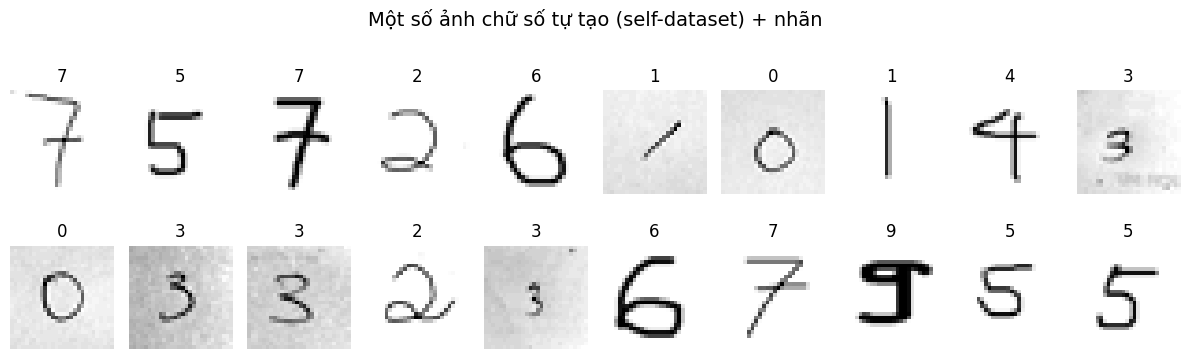

In [5]:
# ====================================================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ====================================================

if x_custom is not None:
    num_show = min(20, len(x_custom))
    idxs = np.random.choice(len(x_custom), size=num_show, replace=False)

    plt.figure(figsize=(12, 4))
    for i, idx in enumerate(idxs):
        img = x_custom[idx].squeeze()
        label = y_custom[idx]

        plt.subplot(2, 10, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(str(label))
    plt.suptitle("Một số ảnh chữ số tự tạo (self-dataset) + nhãn", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Không có self-dataset để hiển thị.")


***Cell 5: Merge MNIST + custom & plot distributions***

Final training set shape:
x_train_full: (60100, 28, 28, 1)
y_train_full: (60100,)


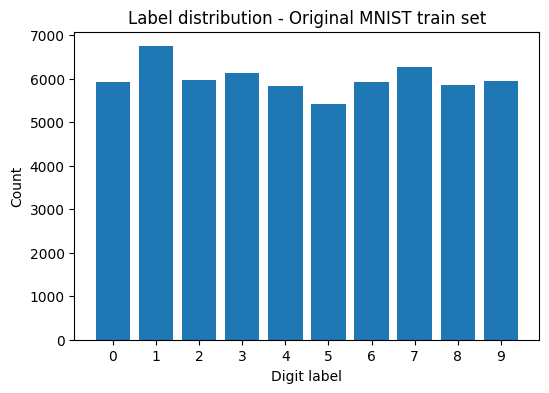

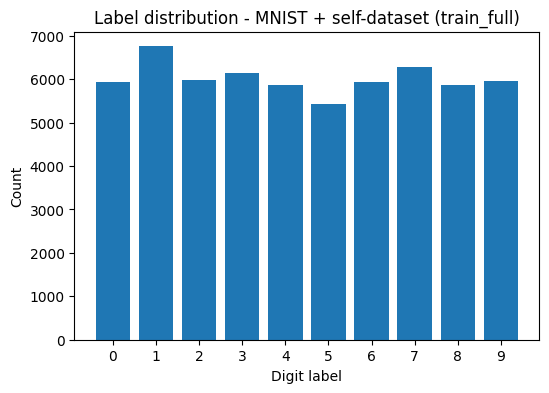

In [6]:
# ====================================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ====================================================

if x_custom is not None:
    x_train_full = np.concatenate([x_train, x_custom], axis=0)
    y_train_full = np.concatenate([y_train, y_custom], axis=0)
else:
    x_train_full = x_train
    y_train_full = y_train

print("Final training set shape:")
print("x_train_full:", x_train_full.shape)
print("y_train_full:", y_train_full.shape)

def plot_label_distribution(y, title):
    counts = np.bincount(y, minlength=10)
    plt.figure(figsize=(6, 4))
    plt.bar(range(10), counts)
    plt.xticks(range(10))
    plt.xlabel("Digit label")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

# Phân bố MNIST gốc
plot_label_distribution(y_train, "Label distribution - Original MNIST train set")

# Phân bố sau khi gộp custom data
plot_label_distribution(y_train_full, "Label distribution - MNIST + self-dataset (train_full)")


***Cell 6: Create train/validation split***

In [7]:
# ==========================================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ==========================================

from sklearn.model_selection import train_test_split

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

print("x_train_final:", x_train_final.shape)
print("y_train_final:", y_train_final.shape)
print("x_val        :", x_val.shape)
print("y_val        :", y_val.shape)
print("x_test       :", x_test.shape)
print("y_test       :", y_test.shape)


x_train_final: (54090, 28, 28, 1)
y_train_final: (54090,)
x_val        : (6010, 28, 28, 1)
y_val        : (6010,)
x_test       : (10000, 28, 28, 1)
y_test       : (10000,)


***Cell 7: Define CNN model using Keras (Model 1)***

In [9]:
# ===================================================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ===================================================

def build_keras_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

keras_model = build_keras_cnn()
keras_model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

***Cell 8: Train Keras CNN model (Model 1)***

In [11]:
# ================================================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ================================================

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

batch_size = 128
epochs = 10  # có thể tăng nếu máy đủ khoẻ

history = keras_model.fit(
    x_train_final, y_train_final,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)


Epoch 1/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9796 - loss: 0.0653 - val_accuracy: 0.9882 - val_loss: 0.0418
Epoch 2/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9822 - loss: 0.0590 - val_accuracy: 0.9877 - val_loss: 0.0419
Epoch 3/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9837 - loss: 0.0531 - val_accuracy: 0.9874 - val_loss: 0.0423
Epoch 4/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9848 - loss: 0.0490 - val_accuracy: 0.9884 - val_loss: 0.0376
Epoch 5/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9861 - loss: 0.0456 - val_accuracy: 0.9897 - val_loss: 0.0386
Epoch 6/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9866 - loss: 0.0439 - val_accuracy: 0.9899 - val_loss: 0.0373
Epoch 7/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9873 - loss: 0.0403 - val_accuracy: 0.9902 - val_loss: 0.0390
Epoch 8/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9881 - loss: 0.0386 - val_accu

***Cell 9: Plot training curves for Keras CNN (Model 1)***

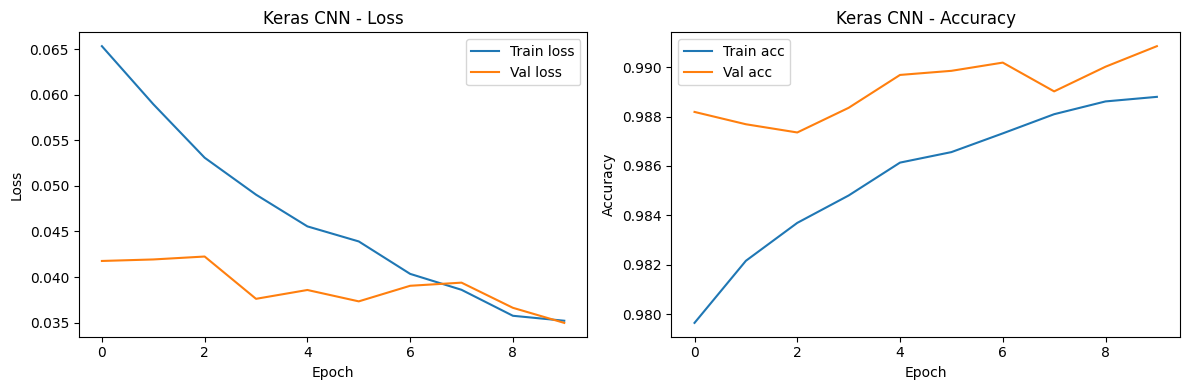

In [12]:
# ===================================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ===================================================

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Keras CNN - Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train acc")
plt.plot(history.history["val_accuracy"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Keras CNN - Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


***Cell 10: Evaluate Keras model on test set***

Keras CNN - Test loss: 0.0231, Test accuracy: 0.9920


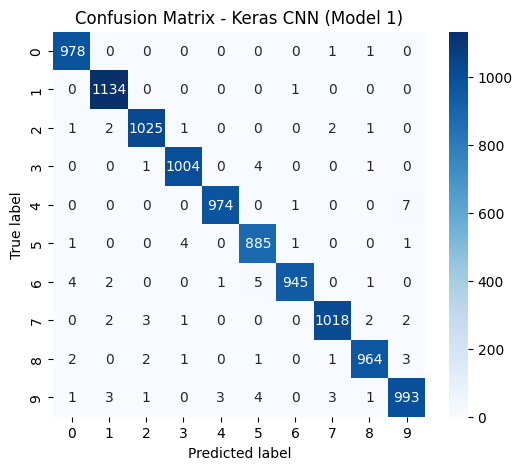

Classification report - Keras CNN:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [13]:
# ===========================================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ===========================================

test_loss_1, test_acc_1 = keras_model.evaluate(x_test, y_test, verbose=0)
print(f"Keras CNN - Test loss: {test_loss_1:.4f}, Test accuracy: {test_acc_1:.4f}")

y_pred_prob_1 = keras_model.predict(x_test, verbose=0)
y_pred_1 = np.argmax(y_pred_prob_1, axis=1)

cm1 = confusion_matrix(y_test, y_pred_1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Keras CNN (Model 1)")
plt.show()

print("Classification report - Keras CNN:")
print(classification_report(y_test, y_pred_1))


***Cell 11: Show some predictions from Keras CNN (Model 1)***

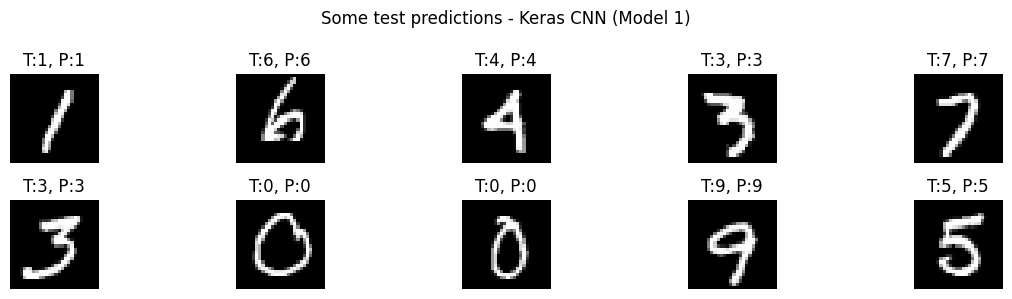

In [14]:
# ======================================================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ======================================================

num_examples = 10
idxs = np.random.choice(len(x_test), size=num_examples, replace=False)

plt.figure(figsize=(12, 3))
for i, idx in enumerate(idxs):
    img = x_test[idx].squeeze()
    true_label = y_test[idx]
    pred_label = y_pred_1[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"T:{true_label}, P:{pred_label}")
plt.suptitle("Some test predictions - Keras CNN (Model 1)")
plt.tight_layout()
plt.show()


***Cell 12: Define CNN model WITHOUT Keras (Model 2)***
Using low-level TensorFlow operations

In [15]:
# ======================================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ======================================================

class TF_CNN_Model(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)

        # Conv1: 32 filters 3x3
        self.W1 = tf.Variable(tf.random.truncated_normal([3, 3, 1, 32], stddev=0.1), name="W1")
        self.b1 = tf.Variable(tf.zeros([32]), name="b1")

        # Conv2: 64 filters 3x3
        self.W2 = tf.Variable(tf.random.truncated_normal([3, 3, 32, 64], stddev=0.1), name="W2")
        self.b2 = tf.Variable(tf.zeros([64]), name="b2")

        # Fully-connected 1: (7*7*64 -> 128)
        self.W3 = tf.Variable(tf.random.truncated_normal([7 * 7 * 64, 128], stddev=0.1), name="W3")
        self.b3 = tf.Variable(tf.zeros([128]), name="b3")

        # Output: 128 -> 10
        self.W4 = tf.Variable(tf.random.truncated_normal([128, 10], stddev=0.1), name="W4")
        self.b4 = tf.Variable(tf.zeros([10]), name="b4")

    @property
    def trainable_variables(self):
        return [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3, self.W4, self.b4]

    def __call__(self, x, training=False, dropout_rate_fc=0.5):
        """
        x: shape (batch, 28, 28, 1)
        """
        # Conv layer 1 + ReLU + MaxPool
        conv1 = tf.nn.conv2d(x, self.W1, strides=[1, 1, 1, 1], padding="SAME")
        conv1 = tf.nn.bias_add(conv1, self.b1)
        conv1 = tf.nn.relu(conv1)
        pool1 = tf.nn.max_pool2d(conv1, ksize=2, strides=2, padding="SAME")  # 14x14

        # Conv layer 2 + ReLU + MaxPool
        conv2 = tf.nn.conv2d(pool1, self.W2, strides=[1, 1, 1, 1], padding="SAME")
        conv2 = tf.nn.bias_add(conv2, self.b2)
        conv2 = tf.nn.relu(conv2)
        pool2 = tf.nn.max_pool2d(conv2, ksize=2, strides=2, padding="SAME")  # 7x7

        # Flatten
        flatten = tf.reshape(pool2, [-1, 7 * 7 * 64])

        # FC1 + ReLU
        fc1 = tf.matmul(flatten, self.W3) + self.b3
        fc1 = tf.nn.relu(fc1)

        # Dropout (chỉ dùng khi training)
        if training:
            fc1 = tf.nn.dropout(fc1, rate=dropout_rate_fc)

        # Output logits
        logits = tf.matmul(fc1, self.W4) + self.b4
        return logits

model2 = TF_CNN_Model()


***Cell 13: Define loss, optimizer, accuracy for Model 2***

In [21]:
# =======================================================
# B22DCCN476 - Đỗ Ngọc Lâm
# =======================================================

optimizer2 = tf.optimizers.Adam(learning_rate=1e-3)

def compute_loss(model, x, y, training=False):
    y = tf.cast(y, tf.int32)
    logits = model(x, training=training)
    loss = tf.reduce_mean(
        tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=logits)
    )
    return loss, logits

def compute_accuracy(logits, y):
    y = tf.cast(y, tf.int32)
    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    correct = tf.equal(preds, y)
    acc = tf.reduce_mean(tf.cast(correct, tf.float32))
    return acc, preds


***Cell 14: Training loop for Model 2***

In [18]:
# ========================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ========================================

batch_size2 = 128
epochs2 = 10  # có thể tăng

train_dataset2 = tf.data.Dataset.from_tensor_slices((x_train_final, y_train_final))
train_dataset2 = train_dataset2.shuffle(buffer_size=1024).batch(batch_size2)

val_dataset2 = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size2)

train_loss_hist2 = []
train_acc_hist2 = []
val_loss_hist2 = []
val_acc_hist2 = []

for epoch in range(1, epochs2 + 1):
    # ---- Train ----
    train_loss_epoch = 0.0
    train_acc_epoch = 0.0
    num_train_batches = 0

    for xb, yb in train_dataset2:
        with tf.GradientTape() as tape:
            loss, logits = compute_loss(model2, xb, yb, training=True)

        grads = tape.gradient(loss, model2.trainable_variables)
        optimizer2.apply_gradients(zip(grads, model2.trainable_variables))

        acc, _ = compute_accuracy(logits, yb)

        train_loss_epoch += loss.numpy()
        train_acc_epoch += acc.numpy()
        num_train_batches += 1

    train_loss_epoch /= num_train_batches
    train_acc_epoch /= num_train_batches

    # ---- Validation ----
    val_loss_epoch = 0.0
    val_acc_epoch = 0.0
    num_val_batches = 0

    for xb, yb in val_dataset2:
        loss, logits = compute_loss(model2, xb, yb, training=False)
        acc, _ = compute_accuracy(logits, yb)

        val_loss_epoch += loss.numpy()
        val_acc_epoch += acc.numpy()
        num_val_batches += 1

    val_loss_epoch /= num_val_batches
    val_acc_epoch /= num_val_batches

    train_loss_hist2.append(train_loss_epoch)
    train_acc_hist2.append(train_acc_epoch)
    val_loss_hist2.append(val_loss_epoch)
    val_acc_hist2.append(val_acc_epoch)

    print(f"Epoch {epoch}/{epochs2} - "
          f"Train loss: {train_loss_epoch:.4f}, Train acc: {train_acc_epoch:.4f} | "
          f"Val loss: {val_loss_epoch:.4f}, Val acc: {val_acc_epoch:.4f}")


Epoch 1/10 - Train loss: 0.0618, Train acc: 0.9810 | Val loss: 0.0538, Val acc: 0.9855
Epoch 2/10 - Train loss: 0.0529, Train acc: 0.9834 | Val loss: 0.0442, Val acc: 0.9858
Epoch 3/10 - Train loss: 0.0468, Train acc: 0.9852 | Val loss: 0.0468, Val acc: 0.9867
Epoch 4/10 - Train loss: 0.0424, Train acc: 0.9868 | Val loss: 0.0440, Val acc: 0.9875
Epoch 5/10 - Train loss: 0.0380, Train acc: 0.9875 | Val loss: 0.0425, Val acc: 0.9875
Epoch 6/10 - Train loss: 0.0352, Train acc: 0.9887 | Val loss: 0.0440, Val acc: 0.9868
Epoch 7/10 - Train loss: 0.0300, Train acc: 0.9901 | Val loss: 0.0424, Val acc: 0.9883
Epoch 8/10 - Train loss: 0.0306, Train acc: 0.9899 | Val loss: 0.0397, Val acc: 0.9895
Epoch 9/10 - Train loss: 0.0263, Train acc: 0.9909 | Val loss: 0.0398, Val acc: 0.9882
Epoch 10/10 - Train loss: 0.0253, Train acc: 0.9915 | Val loss: 0.0382, Val acc: 0.9892


***Cell 15: Plot training curves for Model 2***

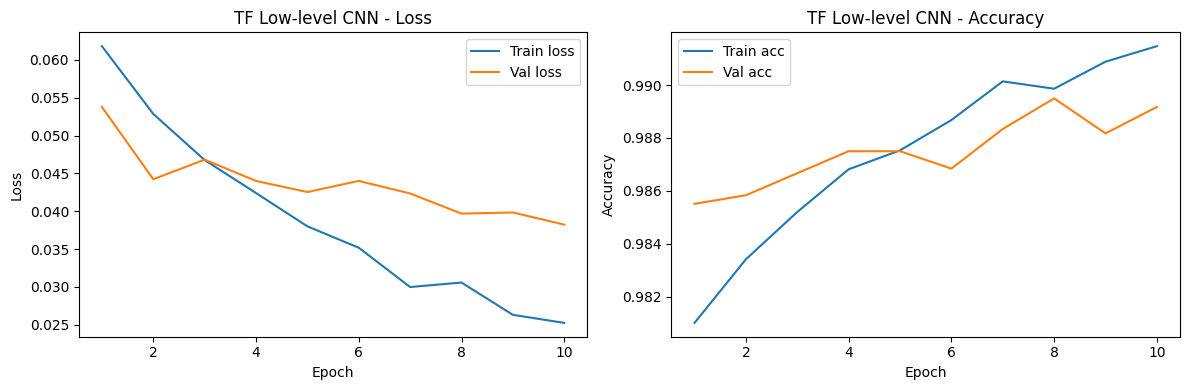

In [19]:
# ===================================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ===================================================

epochs_range = range(1, epochs2 + 1)

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_hist2, label="Train loss")
plt.plot(epochs_range, val_loss_hist2, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TF Low-level CNN - Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_hist2, label="Train acc")
plt.plot(epochs_range, val_acc_hist2, label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TF Low-level CNN - Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


***Cell 16: Evaluate Model 2 on test set***

TF Low-level CNN - Test loss: 0.0249, Test accuracy: 0.9917


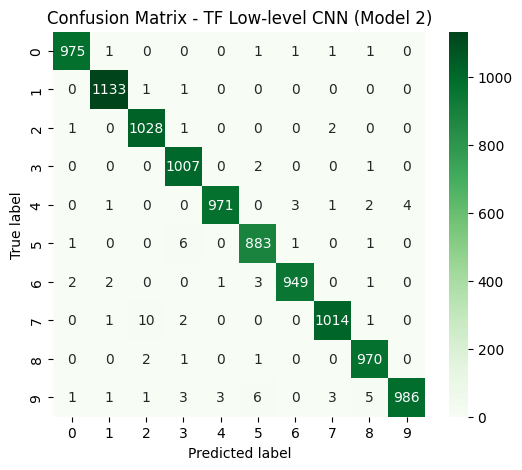

Classification report - TF Low-level CNN:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [22]:
# ===========================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ===========================================

test_dataset2 = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size2)

test_loss_2 = 0.0
test_acc_2 = 0.0
num_test_batches = 0

all_logits = []
all_labels = []

for xb, yb in test_dataset2:
    loss, logits = compute_loss(model2, xb, yb, training=False)
    acc, _ = compute_accuracy(logits, yb)

    test_loss_2 += loss.numpy()
    test_acc_2 += acc.numpy()
    num_test_batches += 1

    all_logits.append(logits.numpy())
    all_labels.append(yb.numpy())

test_loss_2 /= num_test_batches
test_acc_2  /= num_test_batches

print(f"TF Low-level CNN - Test loss: {test_loss_2:.4f}, Test accuracy: {test_acc_2:.4f}")

all_logits = np.concatenate(all_logits, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
y_pred_2 = np.argmax(all_logits, axis=1)

cm2 = confusion_matrix(all_labels, y_pred_2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - TF Low-level CNN (Model 2)")
plt.show()

print("Classification report - TF Low-level CNN:")
print(classification_report(all_labels, y_pred_2))


***Cell 17: Show some predictions from Model 2***

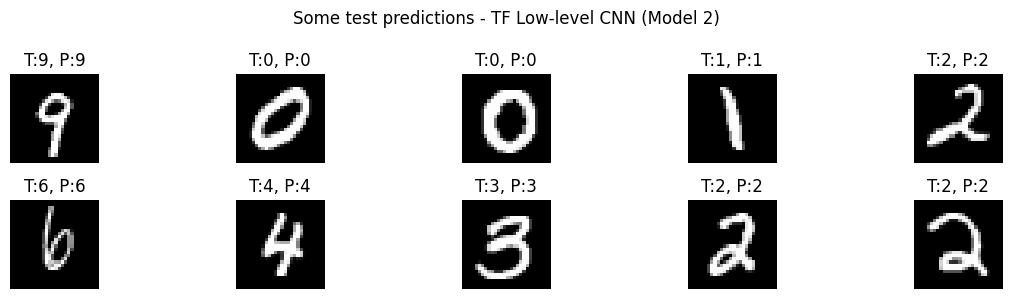

In [23]:
# ======================================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ======================================================

num_examples = 10
idxs = np.random.choice(len(x_test), size=num_examples, replace=False)

plt.figure(figsize=(12, 3))
for i, idx in enumerate(idxs):
    img = x_test[idx]
    true_label = y_test[idx]

    logits = model2(img[None, ...], training=False)
    pred_label = int(tf.argmax(logits, axis=1).numpy()[0])

    plt.subplot(2, 5, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"T:{true_label}, P:{pred_label}")
plt.suptitle("Some test predictions - TF Low-level CNN (Model 2)")
plt.tight_layout()
plt.show()


***Cell 18: Compare the two CNN models***

Keras CNN (Model 1)        - Test accuracy: 0.9920
TF Low-level CNN (Model 2) - Test accuracy: 0.9917
Difference (Model1 - Model2): 0.03 percentage points


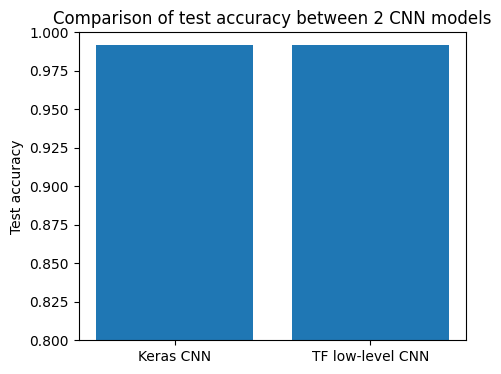

In [24]:
# ======================================
# B22DCCN476 - Đỗ Ngọc Lâm
# ======================================

print(f"Keras CNN (Model 1)        - Test accuracy: {test_acc_1:.4f}")
print(f"TF Low-level CNN (Model 2) - Test accuracy: {test_acc_2:.4f}")

improvement = (test_acc_1 - test_acc_2) * 100
print(f"Difference (Model1 - Model2): {improvement:.2f} percentage points")

plt.figure(figsize=(5, 4))
plt.bar(["Keras CNN", "TF low-level CNN"], [test_acc_1, test_acc_2])
# Nếu acc thấp/higher, em chỉnh ylim cho hợp
plt.ylim(0.8, 1.0)
plt.ylabel("Test accuracy")
plt.title("Comparison of test accuracy between 2 CNN models")
plt.show()
